### Testing the approximation

**Practical approximation test**
* sample smooth exact function directly on nodal grid
* nodal $\to$ modal
* DG vs exact
* SIAC vs exact

Expectation: SIAC improves smooth cases

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../..")

In [17]:
from src.mesh import build_uniform_mesh_1d
from src.grid import local_cell_center_nodes_1d, build_grid_from_local_nodes_1d
from src.siac_modal import apply_siac_to_modal_dg_1d, trim_valid_siac_region_1d
from src.transforms import nodal_to_modal_1d
from src.evaluation import eval_dg_on_local_nodes_1d

In [18]:
# -----------------------------
# 0. Problem / domain setup
# -----------------------------
xmin, xmax = -3, 3
xlim = (xmin, xmax)

# --------------------------------------------------
# 1. Exact test function
# --------------------------------------------------
def exact_sine_scaled(x):
    x = np.asarray(x)
    # xhat = 2.0 * (x - xlim[0]) / (xlim[1] - xlim[0]) - 1.0
    u = np.sin(np.pi*x)
    return u


# DG polynomial degree  
p = 2
order = p + 1

# DG mesh resolution
domain_len = int(np.floor(xmax-xmin))
K = 5*domain_len

# SIAC parameters
moments = 2 * p
BSorder = p + 1

# -----------------------------
# 2. Build DG mesh
# -----------------------------
mesh = build_uniform_mesh_1d(K=K, p=p, domain=xlim)

# -----------------------------
# 3. Create sample grid
# -----------------------------
n_eval = order
nodes = local_cell_center_nodes_1d(n_eval)
grid = build_grid_from_local_nodes_1d(
    mesh=mesh, 
    eval_nodes=nodes
)

# -----------------------------
# 3. Sample function and transform to nodal
# -----------------------------
exact_func = exact_sine_scaled(grid)
Unode = exact_func.reshape(K, order)


# -----------------------------
# 5. transform to modal
# -----------------------------
dg = nodal_to_modal_1d(Unode, mesh=mesh, p=p)

# -----------------------------
# 6. Fine local nodes per element
# -----------------------------
n_eval_fine = 50 * n_eval
nodes_fine = local_cell_center_nodes_1d(n_eval_fine)
grid_fine = build_grid_from_local_nodes_1d(
    mesh=mesh, 
    eval_nodes=nodes_fine
)

# -----------------------------
# 6. Evaluate exact, DG, SIAC
# -----------------------------
U_exact = exact_sine_scaled(
    x=grid_fine
)

U_dg = eval_dg_on_local_nodes_1d(
    dg,
    eval_nodes=nodes_fine
)

U_siac = apply_siac_to_modal_dg_1d(
    dg,
    moments=moments,
    BSorder=BSorder,
    eval_nodes=nodes_fine
)

# -----------------------------
# 7. Trim interior for SIAC comparison
# -----------------------------
n_eval = len(nodes_fine)

exact_trim, trim = trim_valid_siac_region_1d(
    U_exact,
    n_eval=n_eval_fine,
    moments=moments,
    BSorder=BSorder, 
    return_trim=True
)

dg_trim = trim_valid_siac_region_1d(
    U_dg,
    n_eval=n_eval_fine,
    moments=moments,
    BSorder=BSorder
)

siac_trim = trim_valid_siac_region_1d(
    U_siac,
    n_eval=n_eval_fine,
    moments=moments,
    BSorder=BSorder
)

# -----------------------------
# 8. Errors
# -----------------------------
err_dg = dg_trim - exact_trim
err_siac = siac_trim - exact_trim

print(f"DG degree:                  p = {p}")
print(f"SIAC parameters:            r = {moments}, n = {BSorder}")

print("trim =", trim)

print("DG max err   :", np.max(np.abs(err_dg)))
print("DG rel err   :", np.linalg.norm(err_dg) / np.linalg.norm(exact_trim))

print("SIAC max err :", np.max(np.abs(err_siac)))
print("SIAC rel err :", np.linalg.norm(err_siac) / np.linalg.norm(exact_trim))

DG degree:                  p = 2
SIAC parameters:            r = 4, n = 3
trim = 600
DG max err   : 0.002695502623432772
DG rel err   : 0.0009715701480352559
SIAC max err : 0.0001282950622667478
SIAC rel err : 0.00012831048446796767


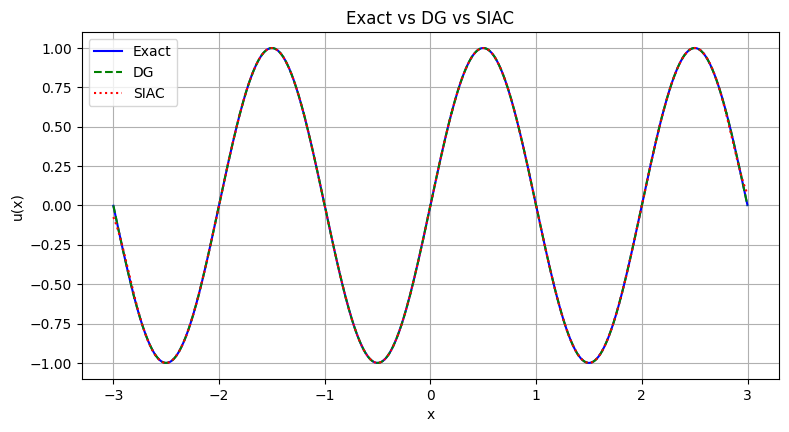

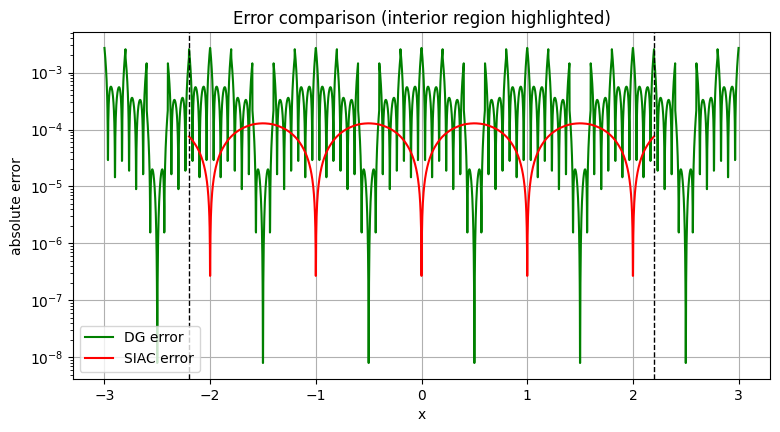

In [19]:
# --------------------------------------------------
# 7. Plots: exact, DG, SIAC
# --------------------------------------------------

# --------------------------------------------------
# 7a. Overlay comparison
# --------------------------------------------------
plt.figure(figsize=(9, 4.5))
plt.plot(grid_fine, U_exact, "-", color="b", label="Exact")
plt.plot(grid_fine, U_dg, "--", color="g", label="DG")
plt.plot(grid_fine, U_siac, ":", color="r", label="SIAC")
plt.title("Exact vs DG vs SIAC")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------------------------
# 7b. Overlay error plot (full grid with NaNs)
# --------------------------------------------------
x_left = grid_fine[trim]
x_right = grid_fine[-trim-1]


siac_err_plot = np.full_like(U_exact, np.nan, dtype=float)
dg_err_plot = U_exact - U_dg

sl = slice(trim, -trim)
siac_err_plot[sl] = np.abs(err_siac)

plt.figure(figsize=(9, 4.5))

plt.semilogy(grid_fine, np.abs(dg_err_plot), color="green", label="DG error")
plt.semilogy(grid_fine, np.abs(siac_err_plot), color="red", label="SIAC error")

plt.axvline(x_left, color="black", linestyle="--", linewidth=1)
plt.axvline(x_right, color="black", linestyle="--", linewidth=1)

plt.title("Error comparison (interior region highlighted)")
plt.xlabel("x")
plt.ylabel("absolute error")
plt.grid(True)
plt.legend()

plt.show()

### Test with noise

In [20]:

# -----------------------------
# 2. Build DG mesh
# -----------------------------
mesh = build_uniform_mesh_1d(K=K, p=p, domain=xlim)

# -----------------------------
# 3. Create sample grid
# -----------------------------
n_eval = order
nodes = local_cell_center_nodes_1d(n_eval)
grid = build_grid_from_local_nodes_1d(
    mesh=mesh, 
    eval_nodes=nodes
)

# -----------------------------
# 3. Sample function and transform to nodal
# -----------------------------
exact_func = exact_sine_scaled(grid)
Unode = exact_func.reshape(K, order)

### Add Noise ###
h = mesh["h"]
rng = np.random.default_rng(seed=62)
sigma = h ** (p + 1)
noise = rng.standard_normal(size=Unode.shape) * sigma
Unode += noise

# -----------------------------
# 5. transform to modal
# -----------------------------
dg = nodal_to_modal_1d(Unode, mesh=mesh, p=p)

# -----------------------------
# 6. Fine local nodes per element
# -----------------------------
n_eval_fine = 50 * n_eval
nodes_fine = local_cell_center_nodes_1d(n_eval_fine)
grid_fine = build_grid_from_local_nodes_1d(
    mesh=mesh, 
    eval_nodes=nodes_fine
)

# -----------------------------
# 6. Evaluate exact, DG, SIAC
# -----------------------------
U_exact = exact_sine_scaled(
    x=grid_fine
)

U_dg = eval_dg_on_local_nodes_1d(
    dg,
    eval_nodes=nodes_fine
)

U_siac = apply_siac_to_modal_dg_1d(
    dg,
    moments=moments,
    BSorder=BSorder,
    eval_nodes=nodes_fine
)

# -----------------------------
# 7. Trim interior for SIAC comparison
# -----------------------------
n_eval = len(nodes_fine)

exact_trim, trim = trim_valid_siac_region_1d(
    U_exact,
    n_eval=n_eval_fine,
    moments=moments,
    BSorder=BSorder, 
    return_trim=True
)

dg_trim = trim_valid_siac_region_1d(
    U_dg,
    n_eval=n_eval_fine,
    moments=moments,
    BSorder=BSorder
)

siac_trim = trim_valid_siac_region_1d(
    U_siac,
    n_eval=n_eval_fine,
    moments=moments,
    BSorder=BSorder
)

# -----------------------------
# 8. Errors
# -----------------------------
err_dg = dg_trim - exact_trim
err_siac = siac_trim - exact_trim

print(f"DG degree:                  p = {p}")
print(f"SIAC parameters:            r = {moments}, n = {BSorder}")

print("trim =", trim)

print("DG max err   :", np.max(np.abs(err_dg)))
print("DG rel err   :", np.linalg.norm(err_dg) / np.linalg.norm(exact_trim))

print("SIAC max err :", np.max(np.abs(err_siac)))
print("SIAC rel err :", np.linalg.norm(err_siac) / np.linalg.norm(exact_trim))

DG degree:                  p = 2
SIAC parameters:            r = 4, n = 3
trim = 600
DG max err   : 0.056457258003561495
DG rel err   : 0.013704687602665112
SIAC max err : 0.011266848536020002
SIAC rel err : 0.006946417232291072


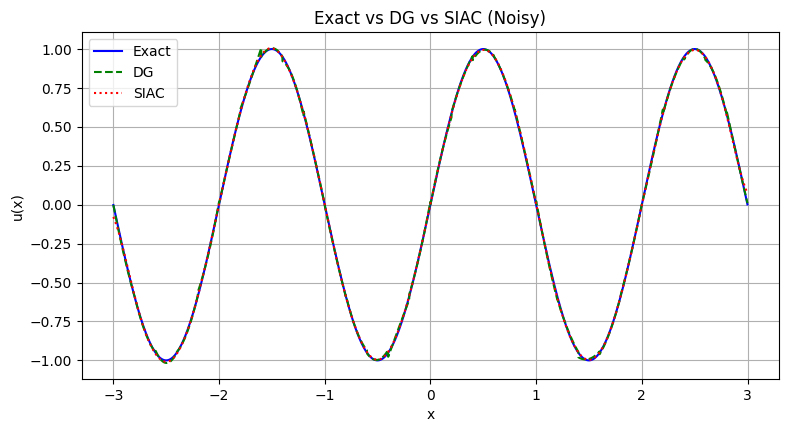

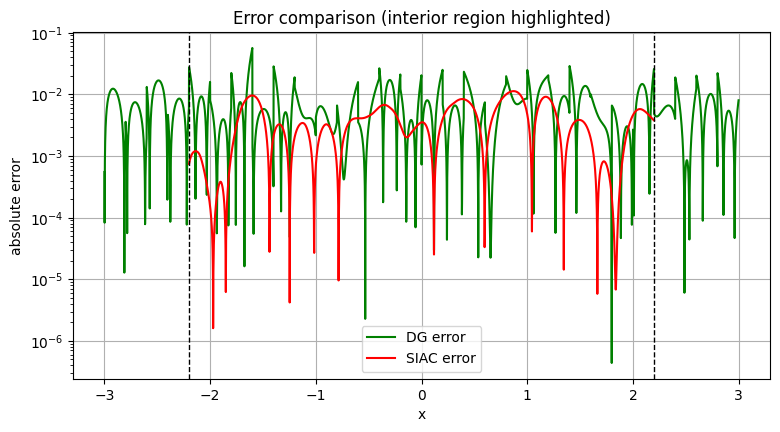

In [21]:
# --------------------------------------------------
# 7. Plots: exact, DG, SIAC
# --------------------------------------------------

# --------------------------------------------------
# 7a. Overlay comparison
# --------------------------------------------------
plt.figure(figsize=(9, 4.5))
plt.plot(grid_fine, U_exact, "-", color="b", label="Exact")
plt.plot(grid_fine, U_dg, "--", color="g", label="DG")
plt.plot(grid_fine, U_siac, ":", color="r", label="SIAC")
plt.title("Exact vs DG vs SIAC (Noisy)")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------------------------
# 7b. Overlay error plot (full grid with NaNs)
# --------------------------------------------------
x_left = grid_fine[trim]
x_right = grid_fine[-trim-1]


siac_err_plot = np.full_like(U_exact, np.nan, dtype=float)
dg_err_plot = U_exact - U_dg

sl = slice(trim, -trim)
siac_err_plot[sl] = np.abs(err_siac)

plt.figure(figsize=(9, 4.5))

plt.semilogy(grid_fine, np.abs(dg_err_plot), color="green", label="DG error")
plt.semilogy(grid_fine, np.abs(siac_err_plot), color="red", label="SIAC error")

plt.axvline(x_left, color="black", linestyle="--", linewidth=1)
plt.axvline(x_right, color="black", linestyle="--", linewidth=1)

plt.title("Error comparison (interior region highlighted)")
plt.xlabel("x")
plt.ylabel("absolute error")
plt.grid(True)
plt.legend()

plt.show()